# VALORA · Análisis y validación del modelo de valoración inmobiliaria

**Anexo técnico del Trabajo Fin de Máster · Data Science, Big Data y Business Analytics**

**Objetivo.** Estimar el precio de oferta de viviendas en Madrid, Barcelona y Valencia a partir de anuncios de 2018 y evaluar hasta qué punto el modelo mejora referencias sencillas de mercado. Se estudian asimismo la incertidumbre de la predicción, la generalización geográfica y temporal dentro de 2018, y la pérdida de precisión cuando se usan únicamente los datos solicitados por la interfaz.

**Datos.** [idealista18](https://github.com/paezha/idealista18), Rey-Blanco et al. (2024), [DOI: 10.1177/23998083241242844](https://doi.org/10.1177/23998083241242844), [licencia ODbL](https://github.com/paezha/idealista18/blob/master/LICENSE.md). La variable de respuesta procede de *anuncios de venta*; no equivale al importe escriturado de las transacciones. La estimación para fechas posteriores a 2018 queda fuera del alcance de esta validación.

Los resultados que siguen proceden de una ejecución del código del proyecto y constituyen evidencia complementaria a la memoria. El repositorio contiene la implementación íntegra y las dependencias necesarias para reproducir el análisis.

## 1. Datos y preparación del entorno

Se emplean los anuncios de venta y los archivos geográficos de las tres ciudades incluidos en el conjunto de datos original. El código de preparación identifica la raíz del proyecto, incorpora los seis archivos de entrada correspondientes y carga las dependencias declaradas en `requirements.txt`. Esta fase permite que las tablas posteriores se calculen a partir de la misma implementación que sirve las predicciones.

In [ ]:
from google.colab import files
from pathlib import Path
import zipfile, subprocess, sys
BASE=Path('/content/tfm_valora');BASE.mkdir(parents=True,exist_ok=True)
files.upload()
project=next((z for z in Path('/content').glob('*.zip') if any(n.endswith('/entrenar.py') or n=='entrenar.py' for n in zipfile.ZipFile(z).namelist())),None)
datazip=next((z for z in Path('/content').glob('*.zip') if z!=project and 'data' in z.name.lower()),None)
assert project and datazip, 'Debes subir los dos ZIP : el de data y el de TFM_valoracion_inmobiliaria'
with zipfile.ZipFile(project) as z:z.extractall(BASE)
ROOT=next((folder for folder in BASE.iterdir() if (folder/'entrenar.py').exists()),None)
assert ROOT, 'No se encuentra entrenar.py dentro del ZIP del proyecto'
with zipfile.ZipFile(datazip) as z:
    for member in z.namelist():
        if member.startswith('data/') and member.endswith('.rda'):
            dest=ROOT/member;dest.parent.mkdir(parents=True,exist_ok=True);dest.write_bytes(z.read(member))
assert (ROOT/'data/Madrid_Sale.rda').exists()
subprocess.run([sys.executable,'-m','pip','-q','install','-r',str(ROOT/'requirements.txt')],check=True)
print('Listo:',ROOT)


## 2. Calidad de datos, partición y entrenamiento

**Propósito.** Evitar que anuncios repetidos o registros incompatibles con el dominio de la aplicación distorsionen el ajuste. Se elimina la repetición de un mismo `ASSETID` en un trimestre y se excluyen observaciones que incumplen los rangos de precio, superficie o localización establecidos en `modelado.py`; los anuncios sin distrito asignable se contabilizan por separado. La tabla presenta el número de filas en cada etapa y deja auditable el tamaño efectivo de la muestra.

**Diseño de evaluación.** Se separan por identificador del inmueble, sin compartir activos entre particiones, aproximadamente el 70 % de los registros para entrenamiento, el 15 % para calibración de intervalos y el 15 % para prueba final. Los porcentajes exactos pueden variar por el agrupamiento. `PRICE` y `UNITPRICE` definen la respuesta y no entran como predictores. Se ajustan tres modelos XGBoost para los cuantiles 0,10, 0,50 y 0,90 de log(€/m²); la conversión a euros multiplica por la superficie construida. El conjunto de calibración sirve para ajustar las bandas mediante la función implementada en `modelado.py`, mientras que el test permanece separado hasta la evaluación.

In [ ]:
import json, pandas as pd, numpy as np, matplotlib.pyplot as plt
subprocess.run([sys.executable,'entrenar.py'],cwd=ROOT,check=True)
summary=json.loads((ROOT/'artefactos/resumen.json').read_text())
flow={city:json.loads((ROOT/'artefactos'/f'{city.lower()}_meta.json').read_text())['flujo'] for city in summary}
display(pd.DataFrame(flow).T)


,inicial,duplicados_asset_period,excluidos_por_rango_o_ubicacion,final,sin_distrito
Madrid,94815,19011,215,75513,76
Barcelona,61486,14757,49,46566,114
Valencia,33622,6231,63,27294,34


**Lectura del flujo.** De 94.815, 61.486 y 33.622 registros iniciales quedan 75.513 anuncios válidos en Madrid, 46.566 en Barcelona y 27.294 en Valencia, respectivamente. La mayor reducción procede de los duplicados de activo y trimestre (19.011, 14.757 y 6.231). Las filas sin distrito asignado se quitan antes del modelado y aparecen en una columna propia para no confundirlas con los descartes por rangos o ubicación.

## 3. Comparación con referencias y evaluación final

**Propósito.** Comprobar que el mayor esfuerzo de modelización aporta una mejora medible frente a dos predicciones de referencia: mediana de €/m² de la ciudad y mediana de €/m² del distrito, multiplicadas por la superficie. Ambas medianas se calculan solo con entrenamiento; los tres métodos se evalúan sobre las mismas viviendas del test.

El **MAE** expresa el error absoluto medio en euros; el **RMSE** penaliza más los errores grandes; la **mediana del error porcentual absoluto** permite comparar inmuebles de distinto precio; y **R²** resume la variación explicada frente a una predicción constante. La cobertura indica qué fracción de anuncios de test queda dentro del intervalo estimado; el ancho mediano expresa la amplitud de ese intervalo en euros. Cobertura y amplitud deben interpretarse conjuntamente: una banda amplia puede cubrir muchos casos y seguir siendo poco informativa.

,ciudad,metodo,n,mae_eur,rmse_eur,mediana_error_pct,r2
0,Madrid,baseline_ciudad,11327,138297.51,225051.81,33.91,0.62
1,Madrid,baseline_distrito,11327,84657.94,152307.14,18.63,0.83
2,Madrid,modelo,11327,58719.49,112893.21,11.79,0.90
3,Barcelona,baseline_ciudad,6985,92082.62,134701.98,19.96,0.73
4,Barcelona,baseline_distrito,6985,75101.34,110639.43,16.38,0.82
5,Barcelona,modelo,6985,54605.10,84501.98,11.29,0.90
6,Valencia,baseline_ciudad,4095,71256.25,131116.81,30.58,0.44
7,Valencia,baseline_distrito,4095,52983.07,97830.08,22.45,0.69
8,Valencia,modelo,4095,34134.65,67550.63,13.45,0.85


,n_test,cobertura_2018,ancho_mediano_eur
Madrid,11327.0,0.8226,131430.57
Barcelona,6985.0,0.8102,143864.76
Valencia,4095.0,0.8059,81903.14


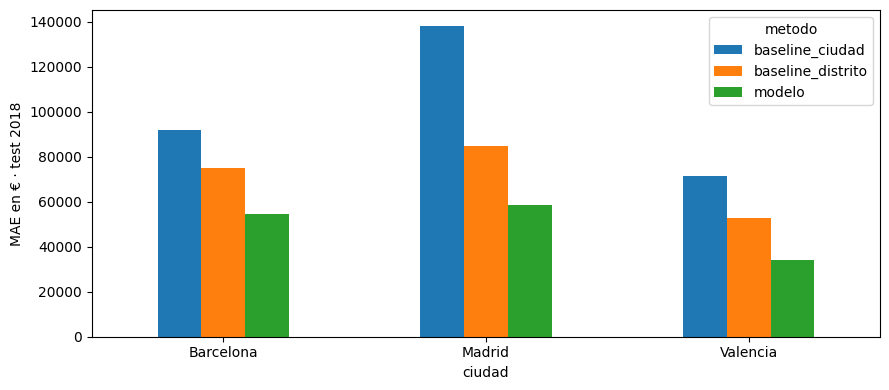

In [ ]:
rows=[{'ciudad':city,'metodo':name,**values[name]} for city,values in summary.items() for name in ('baseline_ciudad','baseline_distrito','modelo')]
results=pd.DataFrame(rows)
display(results.round(2))
display(pd.DataFrame({city:{'n_test':r['n_test'],'cobertura_2018':r['cobertura_2018'],'ancho_mediano_eur':r['ancho_mediano_2018_eur']} for city,r in summary.items()}).T)
results.pivot(index='ciudad',columns='metodo',values='mae_eur').plot.bar(figsize=(9,4),rot=0,ylabel='MAE en € · test 2018')
plt.tight_layout();plt.show()


**Lectura de resultados.** El modelo obtiene el menor MAE de los tres métodos en cada ciudad. La referencia de distrito supera a la de ciudad, lo que indica que incluso una localización sencilla aporta información; el modelo vuelve a mejorarla entre un 27,3 % y un 35,6 % en MAE. Los 11.327, 6.985 y 4.095 casos de test permiten evaluar Madrid, Barcelona y Valencia, respectivamente. La cobertura se ha medido en el test de 2018 y debe presentarse junto con el ancho mediano de cada banda; no constituye una garantía individual para una vivienda ni valida años posteriores.

## 4. Robustez geográfica, temporal y por distrito

**Propósito.** Poner a prueba supuestos más exigentes que la partición aleatoria agrupada. En la prueba **espacial** se entrenó un modelo distinto sin determinados distritos completos y se evaluó en ellos: mide la transferencia a zonas ausentes del entrenamiento. En la prueba **temporal**, otro modelo se entrenó con los tres primeros trimestres de 2018 y se evaluó en anuncios del cuarto trimestre correspondientes a activos no observados antes. Ninguno de estos resultados equivale a una validación fuera de 2018.

Las tablas por distrito describen el test principal, no los conjuntos de las otras dos pruebas: presentan los tres distritos con menor y mayor MAE de cada ciudad entre los que tienen al menos 30 anuncios de prueba. El MAE en euros depende también de los precios habituales de cada zona; para juzgar diferencias de precisión conviene contrastarlo con el error porcentual y el tamaño de la muestra.

In [ ]:
display(pd.DataFrame([{'ciudad':c,**r['espacial_distritos_nuevos']} for c,r in summary.items()]))
display(pd.DataFrame([{'ciudad':c,**r.get('temporal_q4_nuevos',{})} for c,r in summary.items()]))
for city in summary:
    error=pd.DataFrame(json.loads((ROOT/'artefactos'/f'{city.lower()}_error_distrito.json').read_text())).T.sort_values('mae_eur')
    print(city);display(pd.concat([error.head(3),error.tail(3)]))


,ciudad,n,mae_eur,rmse_eur,mediana_error_pct,r2,distritos
0,Madrid,16978,73013.22,126012.86,15.34,0.8877,"[Arganzuela, Chamberí, Moncloa, San Blas, Vill..."
1,Barcelona,8612,54243.00,80633.79,15.57,0.8121,"[Ciutat Vella, Nou Barris]"
2,Valencia,6854,40826.85,73528.55,17.91,0.8377,"[Algirós, Ciutat Vella, L'Olivereta, Rascanya]"


,ciudad,n,mae_eur,rmse_eur,mediana_error_pct,r2
0,Madrid,31298,65340.17,127922.33,12.26,0.8931
1,Barcelona,16483,57335.43,89777.25,11.39,0.8872
2,Valencia,10167,39652.00,81920.71,14.25,0.8094


Madrid


,n,mae_eur,rmse_eur,mediana_error_pct,r2,cobertura_2018
Villaverde,428.0,22493.44,35065.97,12.07,0.6714,0.7921
Puente de Vallecas,646.0,24008.97,34342.46,13.39,0.6885,0.8065
Vicálvaro,146.0,24437.94,32281.89,9.46,0.7897,0.8493
Moncloa,373.0,93756.60,149581.35,12.46,0.8689,0.8338
Chamartín,568.0,110965.66,196066.38,13.22,0.8579,0.8046
Salamanca,998.0,113151.18,188612.84,12.96,0.8860,0.7986


Barcelona


,n,mae_eur,rmse_eur,mediana_error_pct,r2,cobertura_2018
Nou Barris,421.0,28109.07,41993.39,11.66,0.7325,0.8005
Sant Andreu,446.0,30512.94,42725.99,9.51,0.8060,0.8543
Sants-Montjuïc,830.0,40618.66,58314.16,11.02,0.6302,0.8181
Les Corts,273.0,62445.46,95104.81,10.23,0.9458,0.8645
Eixample,1601.0,64944.90,92616.64,11.19,0.8430,0.8057
Sarrià-Sant Gervasi,565.0,114347.28,160188.35,12.86,0.8442,0.7540


Valencia


,n,mae_eur,rmse_eur,mediana_error_pct,r2,cobertura_2018
Rascanya,299.0,18035.33,26031.76,14.05,0.8789,0.8060
Jesús,286.0,18847.74,30524.06,12.48,0.7345,0.8182
Benicalap,268.0,18872.58,26691.17,11.86,0.8608,0.8209
Ciutat Vella,328.0,62348.92,95975.18,14.68,0.8418,0.7927
L'Eixample,301.0,72290.11,129811.22,13.22,0.7866,0.7807
El Pla del Real,161.0,73986.61,130853.84,14.03,0.7878,0.7702


**Lectura de robustez.** Las pruebas espacial y temporal tienen conjuntos de evaluación, tamaños y modelos distintos del test principal; sus MAE no forman una clasificación directa de algoritmos. En Madrid, por ejemplo, el MAE pasa de 58.719 € en el test principal a 73.013 € en distritos ausentes del entrenamiento; las cifras identifican sensibilidad a un cambio de contexto, sin cuantificar el comportamiento de todos los distritos posibles. Las tablas por distrito localizan zonas con errores dispares, pero una muestra pequeña o precios más altos pueden aumentar la variación del indicador.

## 5. Ablación de localización y disponibilidad de variables en la interfaz

**Propósito.** Identificar qué parte del rendimiento requiere datos que pueden faltar al utilizar la aplicación. La ablación reentrena el algoritmo sin coordenadas ni distancias geográficas y compara su MAE en el mismo test. La segunda prueba mantiene el modelo principal, pero sustituye los atributos no solicitados por la interfaz por las medianas calculadas únicamente en entrenamiento.

La simulación de la interfaz conserva la ubicación y otros campos observados de los anuncios de prueba: por tanto, constituye una aproximación al uso con datos parciales, no una medición del error en viviendas introducidas por personas reales. La cobertura de los intervalos calibrados con todos los atributos no queda acreditada para entradas parciales.

In [ ]:
display(pd.DataFrame([
    {'ciudad':city,'modelo_completo_mae':v['modelo']['mae_eur'],
     'sin_localizacion_mae':v['ablacion_sin_localizacion']['mae_eur'],
     'solo_campos_app_mae':v['simulacion_campos_app']['mae_eur']}
    for city,v in summary.items()]))


,ciudad,modelo_completo_mae,sin_localizacion_mae,solo_campos_app_mae
0,Madrid,58719.49,84032.00,81879.19
1,Barcelona,54605.10,66038.83,63720.86
2,Valencia,34134.65,43619.72,52269.78


**Lectura de la comparación.** Sin localización, el MAE aumenta de 58.719 a 84.032 € en Madrid, de 54.605 a 66.039 € en Barcelona y de 34.135 a 43.620 € en Valencia: la ubicación contribuye al rendimiento del sistema. Al limitar las variables a los campos de la interfaz, el MAE también aumenta, especialmente en Madrid (81.879 €). Esta última evaluación no sustituye a una prueba con entradas reales de usuarios y direcciones aproximadas.

## 6. Interpretación del modelo

**Propósito.** Examinar las variables asociadas a la predicción mediante las contribuciones SHAP nativas del modelo mediano de Madrid, calculadas en una muestra reproducible de 500 anuncios depurados. Se representa la media de los valores absolutos para resumir la magnitud habitual de cada contribución, sin atribuir un signo único a la variable.

Las contribuciones se expresan en la escala de entrenamiento, **log(€/m²)**: no son euros, porcentajes de subida del precio ni efectos causales. Las variables de localización están correlacionadas entre sí, por lo que su reparto de importancia depende de la estructura del modelo y de los datos.

,"SHAP absoluto medio, escala log €/m²"
LATITUDE,0.164711
DISTANCE_TO_CASTELLANA,0.125967
DISTANCE_TO_CITY_CENTER,0.086048
HASLIFT,0.049346
CONSTRUCTEDAREA,0.042647
CADASTRALQUALITYID,0.033835
HASSWIMMINGPOOL,0.029083
LONGITUDE,0.026036
FLOORCLEAN,0.019208
HASAIRCONDITIONING,0.019085


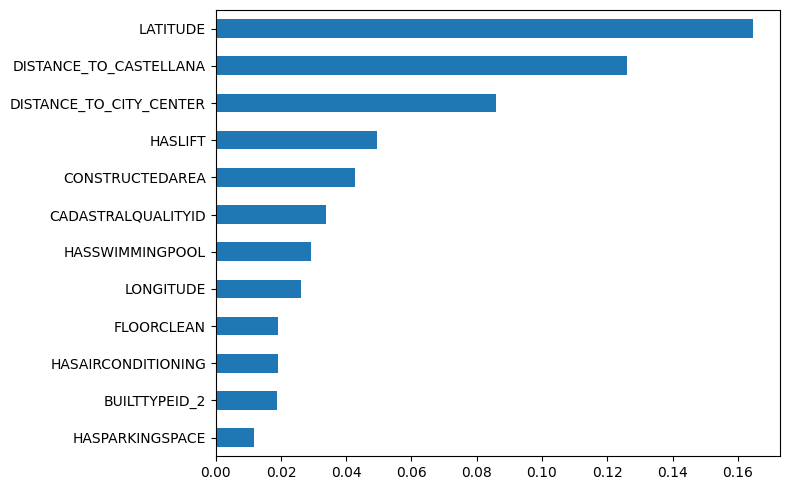

In [ ]:
import xgboost as xgb
sys.path.insert(0,str(ROOT))
from geografia import leer_rda
from modelado import limpiar, preparar
meta=json.loads((ROOT/'artefactos/madrid_meta.json').read_text())
raw=pd.DataFrame(leer_rda('Madrid_Sale.rda','Madrid_Sale')).drop(columns='geometry',errors='ignore')
raw,_=limpiar(raw)
X=preparar(raw.sample(500,random_state=42),meta['features'])
booster=xgb.Booster(model_file=str(ROOT/'artefactos/madrid_q50.ubj'))
contrib=booster.predict(xgb.DMatrix(X),pred_contribs=True)
assert contrib.shape[1]==len(X.columns)+1
imp=pd.Series(np.abs(contrib[:,:-1]).mean(axis=0),index=X.columns).sort_values(ascending=False)
display(imp.head(15).rename('SHAP absoluto medio, escala log €/m²'))
imp.head(12).sort_values().plot.barh(figsize=(8,5));plt.tight_layout();plt.show()


**Lectura de SHAP.** En esta muestra de Madrid, latitud y distancias a la Castellana y al centro figuran entre las variables con mayores contribuciones absolutas medias. Su importancia es descriptiva: la coexistencia de varias medidas de posición y las posibles diferencias entre barrios impiden interpretar esos valores como el cambio causal de precio que produciría modificar una coordenada o una característica.

## 7. Discusión, alcance y conclusiones

El modelo reduce el MAE del test de 2018 respecto de la referencia por distrito de **84.657,94 a 58.719,49 € en Madrid** (−30,6 %), de **75.101,34 a 54.605,10 € en Barcelona** (−27,3 %) y de **52.983,07 a 34.134,65 € en Valencia** (−35,6 %). La cobertura observada de los intervalos se sitúa entre **80,59 % y 82,26 %**, con anchos medianos de **81.903 a 143.865 €** aproximadamente: se trata de estimaciones acompañadas de incertidumbre, no de tasaciones exactas.

Los experimentos complementarios muestran que el resultado depende de la información disponible y del lugar y momento de evaluación. La simulación con campos de la interfaz arroja un MAE de **81.879,19 €** en Madrid, **63.720,86 €** en Barcelona y **52.269,78 €** en Valencia, superior al del test con todas las variables. La prueba temporal se limita al último trimestre de 2018; la espacial, a los distritos seleccionados y al modelo reentrenado para esa prueba. Ninguna permite extrapolar automáticamente el error a anuncios actuales.

Las principales limitaciones son el uso de **precios anunciados y no de compraventas**, la calidad y cobertura de los atributos y de las coordenadas, el tamaño desigual de los distritos y el desfase temporal entre 2018 y una eventual aplicación presente. Antes de utilizar la estimación para decisiones actuales sería necesario reunir ofertas o transacciones recientes, comprobar cambios de distribución, repetir la evaluación con las entradas reales de la interfaz y volver a calibrar y medir los intervalos en esas condiciones. La interpretación SHAP describe asociaciones del modelo y no demuestra efectos causales sobre el mercado.